In [15]:

# # Feature Extraction for Time Series Clustering
# ##  - KDDSS 2026 Project
# 
# This notebook extracts features from the 2023 energy consumption data for clustering.

# ## 1. Setup and Imports

# %%
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, RANDOM_SEED
from src.data_loader import load_data
from src.feature_engineering import extract_all_features, normalize_features

# Set random seed
np.random.seed(RANDOM_SEED)


In [16]:
# ## 2. Load the Data

df_2023, df_2024 = load_data()
print(f"\n2023 data shape: {df_2023.shape}")


LOADING DATA

✅ Loaded 2023 data:
   - Shape: (17547, 366)
   - Number of households: 17547
   - Number of days (2023): 365

✅ Loaded 2024 data:
   - Shape: (17547, 367)
   - Number of households: 17547
   - Number of days (2024 leap year): 366

2023 data shape: (17547, 366)


In [5]:
# ## 3. Extract Features
# Extract features from all households
features_df = extract_all_features(df_2023)

# Display first few rows
print("\n First 5 rows of extracted features:")
features_df.head()

# Check feature statistics
print("\n Feature Statistics:")
features_df.describe()

EXTRACTING FEATURES FROM TIME SERIES
   Processed 1000 households...
   Processed 2000 households...
   Processed 3000 households...
   Processed 4000 households...
   Processed 5000 households...
   Processed 6000 households...
   Processed 7000 households...
   Processed 8000 households...
   Processed 9000 households...
   Processed 10000 households...
   Processed 11000 households...
   Processed 12000 households...
   Processed 13000 households...
   Processed 14000 households...
   Processed 15000 households...
   Processed 16000 households...
   Processed 17000 households...

✅ Extracted 26 features for 17547 households

 First 5 rows of extracted features:

 Feature Statistics:


,ID,mean,median,std,cv,iqr,range,skewness,kurtosis,q25,...,trend_r2,seasonal_strength_weekly,n_peaks,peak_density,avg_peak_height,max_peak_height,peak_height_ratio,zero_percentage,max_zero_run,avg_zero_run
count,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17393.000000,17393.000000,17547.000000,...,1.739300e+04,17393.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000
mean,153265.984898,9.131048,8.231127,4.506049,0.550135,5.923719,24.528442,1.156065,4.438153,5.746358,...,4.717694e-02,0.495842,20.042970,20.042970,18.632638,27.020914,3.922267,2.631929,6.187325,4.754301
std,88233.186987,9.405481,8.829385,5.728846,0.770893,8.709676,30.278682,1.480443,19.118903,6.506336,...,8.482040e-02,0.253055,7.049683,7.049683,21.938740,30.693930,11.584405,13.591494,39.312290,36.184207
min,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.021585,-1.982007,0.000000,...,2.000262e-10,-0.023482,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,77002.500000,3.869212,3.414000,1.568962,0.306619,1.879000,9.113500,0.473151,0.022766,2.262500,...,3.288345e-03,0.285368,15.000000,15.000000,7.383249,10.585000,2.136807,0.000000,0.000000,0.000000
50%,153934.000000,6.776293,6.198000,2.615201,0.406868,3.175000,15.518000,0.848219,0.906705,4.350000,...,1.615147e-02,0.460078,21.000000,21.000000,12.459963,17.932000,2.607806,0.000000,0.000000,0.000000
75%,230109.000000,11.356133,10.259000,4.894331,0.582177,5.797500,28.294500,1.392778,2.899835,7.431500,...,5.167576e-02,0.704463,25.000000,25.000000,21.914476,31.852000,3.423427,0.000000,0.000000,0.000000
max,304933.000000,188.015227,185.681000,91.856554,19.078784,162.360000,1051.739571,19.026370,360.002747,145.274000,...,9.170437e-01,0.992197,51.000000,51.000000,1051.739571,1051.739571,365.000000,100.000000,365.000000,365.000000


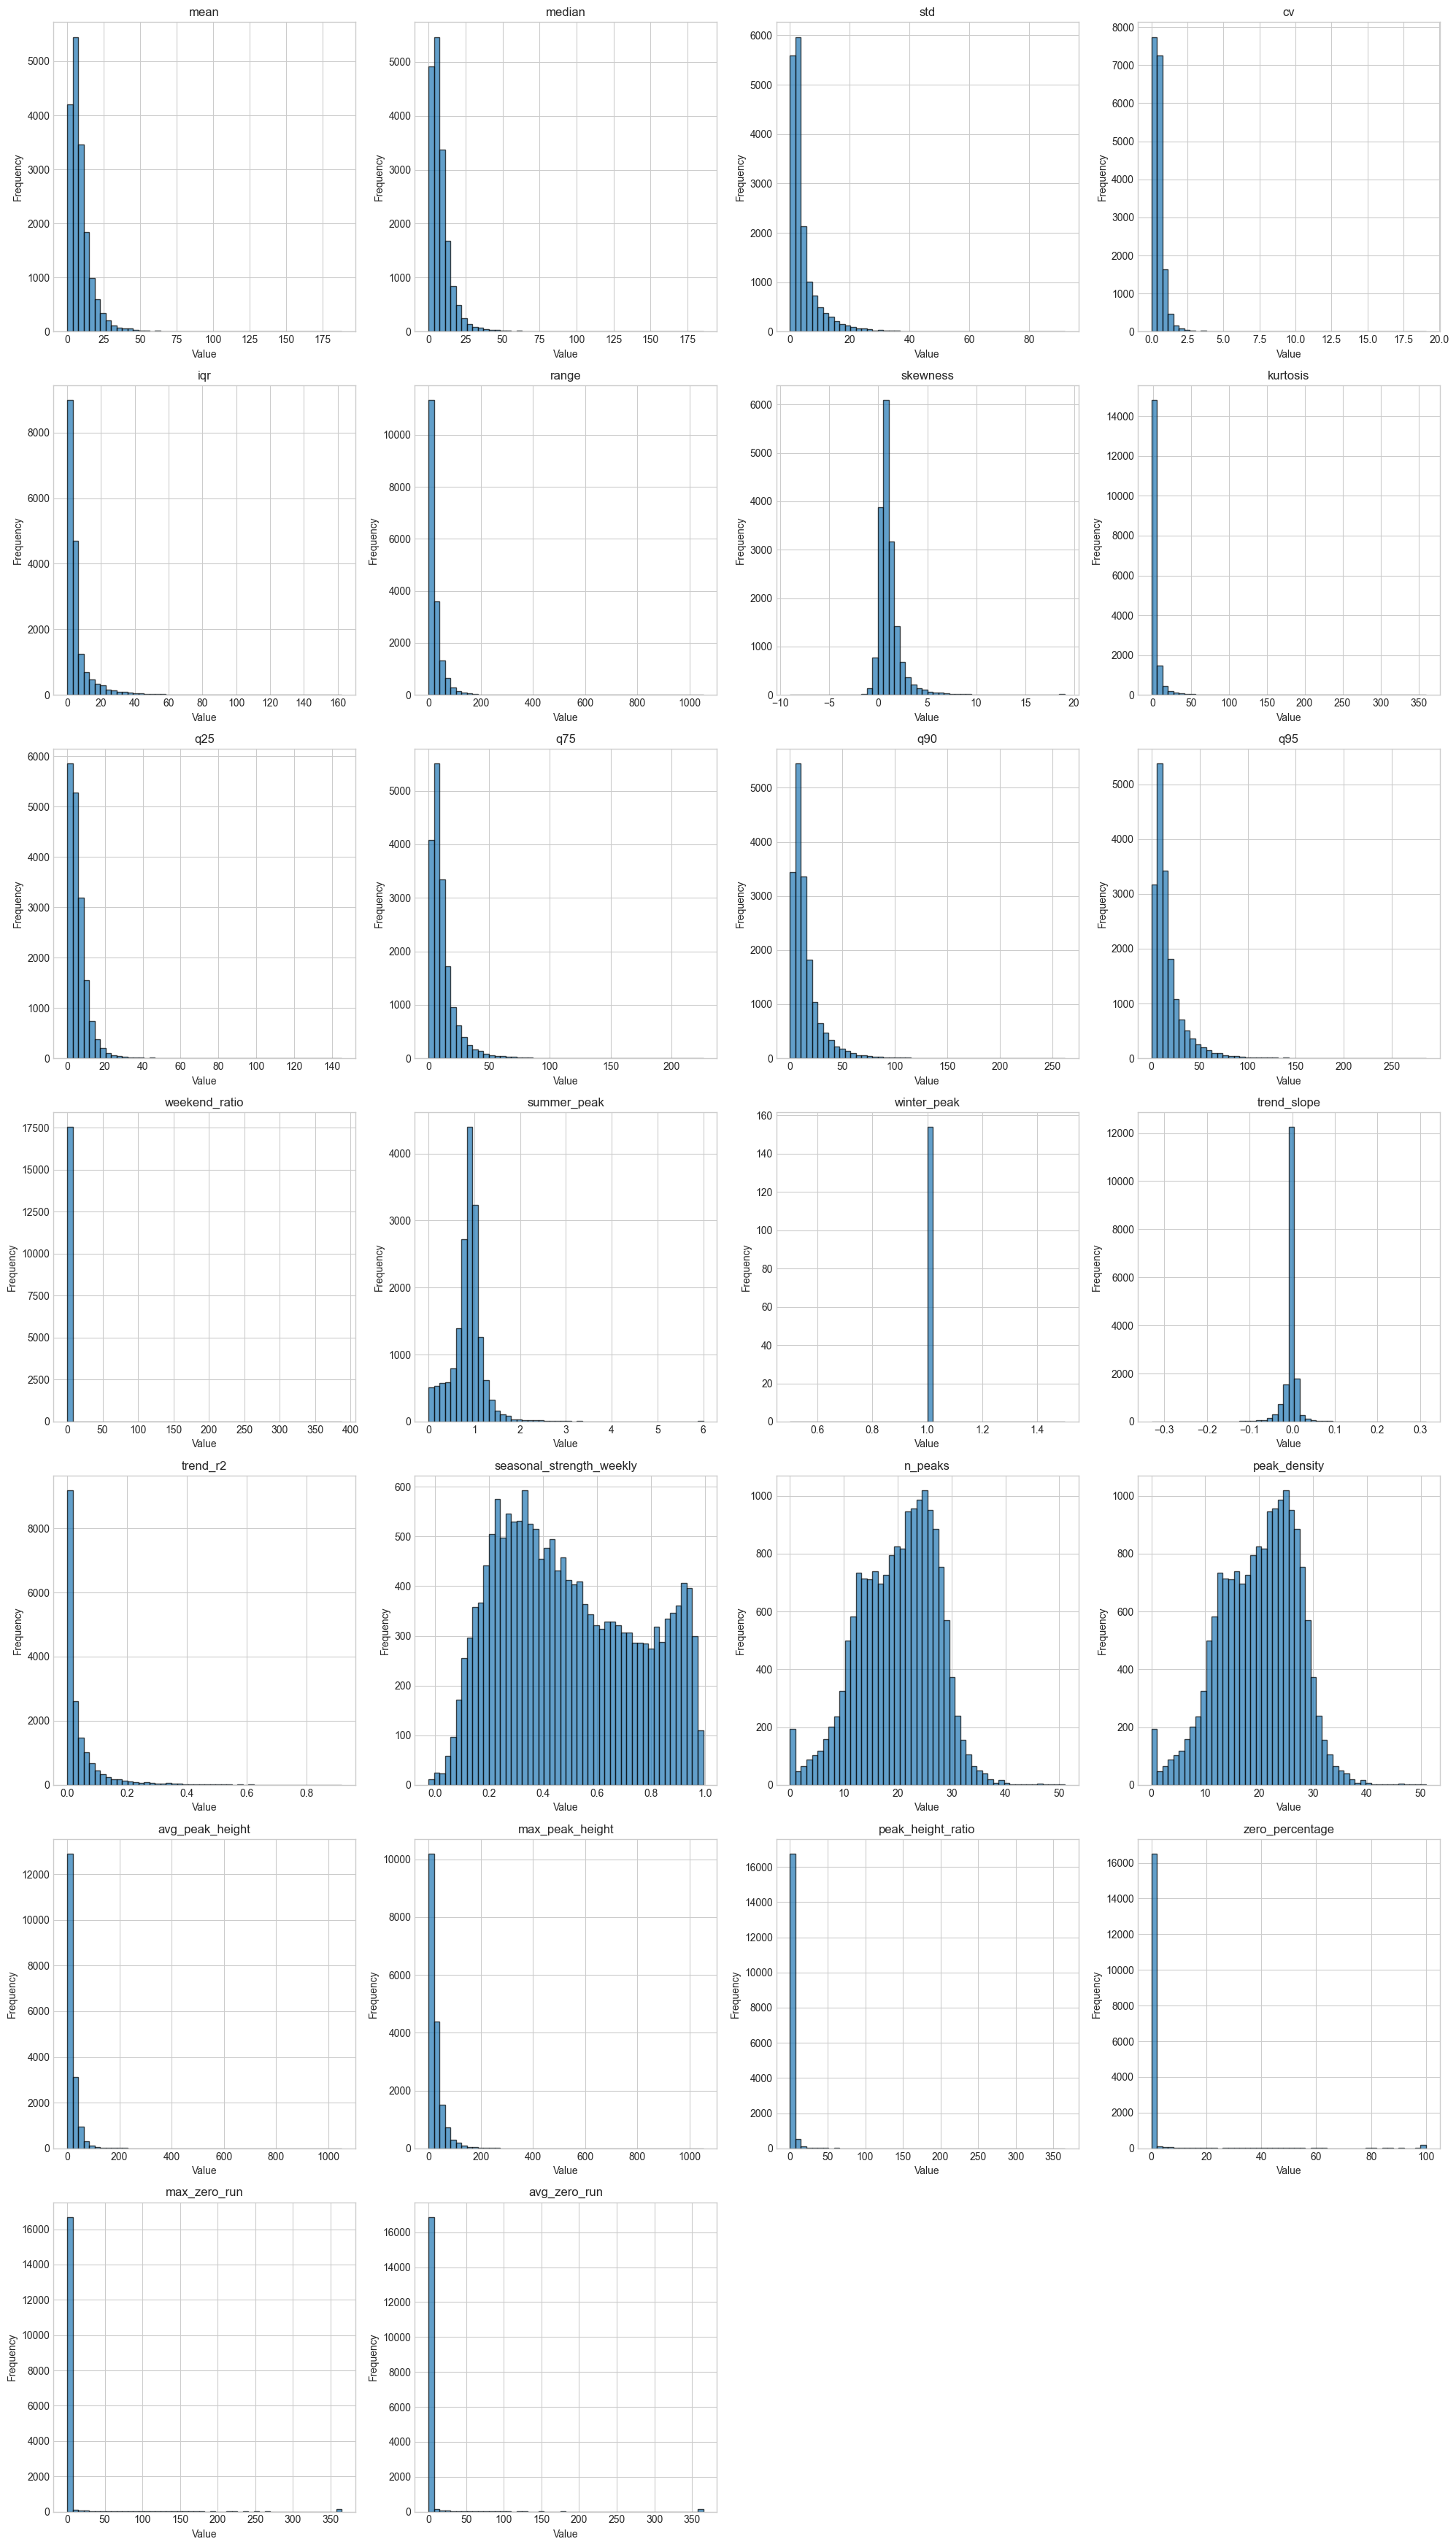

In [6]:
# ## 4. Feature Analysis
# Plot feature distributions

feature_cols = [col for col in features_df.columns if col != 'ID']
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    axes[i].hist(features_df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(feature)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


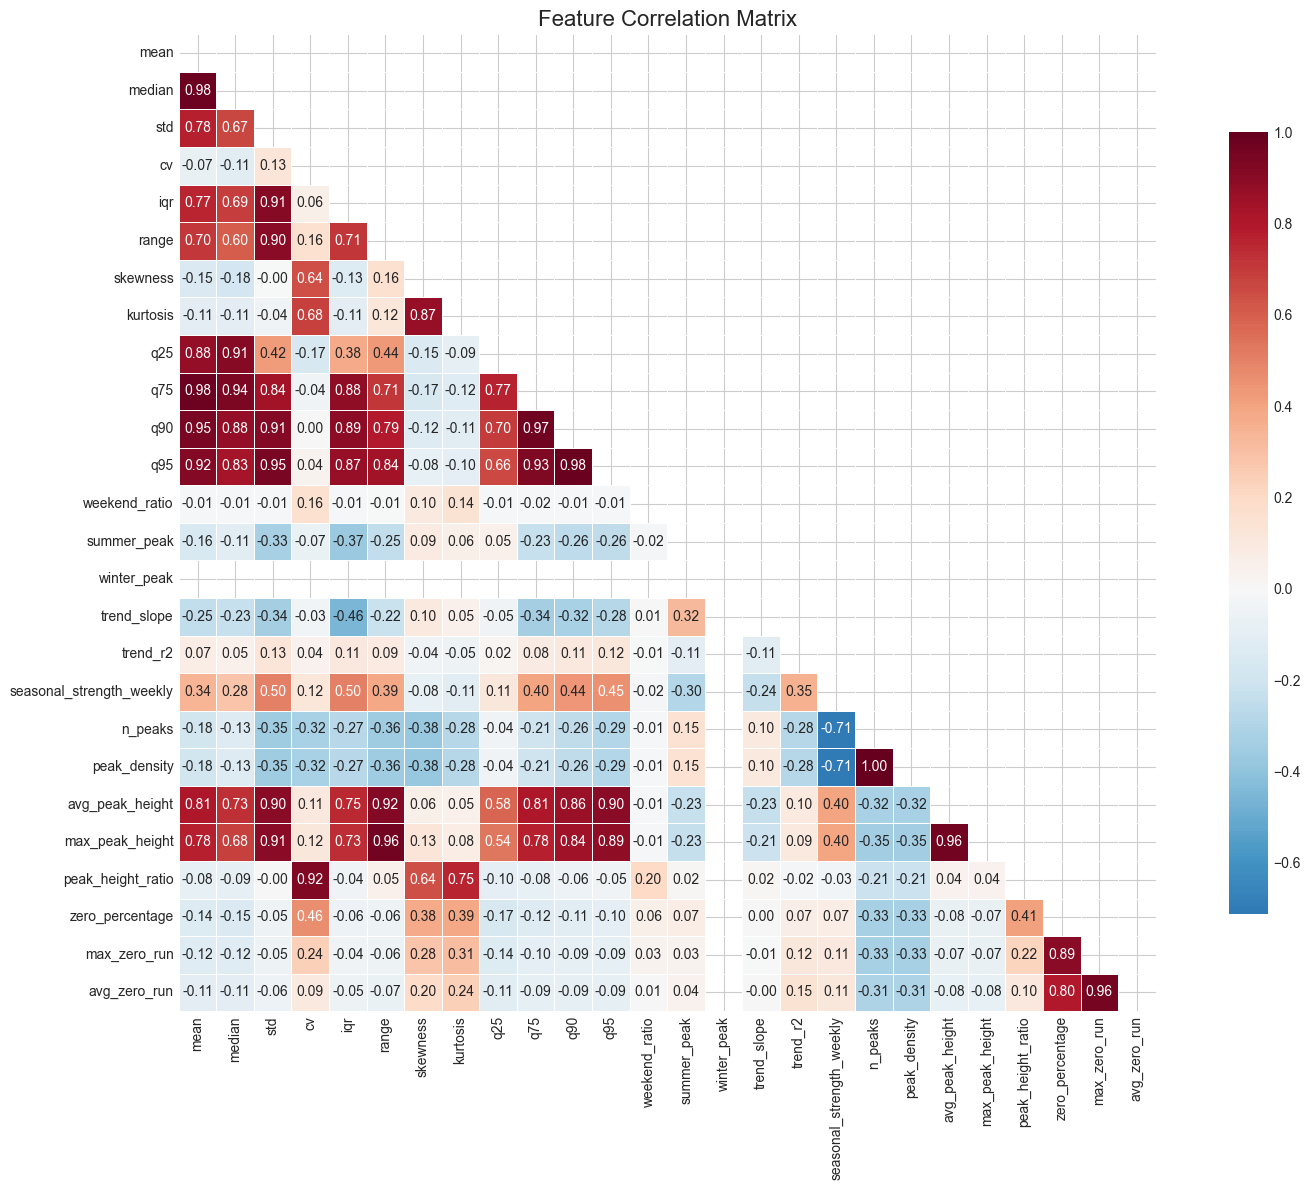


🔗 Highly correlated features (|r| > 0.8):
   mean ↔ median: 0.977
   mean ↔ q25: 0.879
   mean ↔ q75: 0.976
   mean ↔ q90: 0.947
   mean ↔ q95: 0.918
   mean ↔ avg_peak_height: 0.811
   median ↔ q25: 0.911
   median ↔ q75: 0.939
   median ↔ q90: 0.876
   median ↔ q95: 0.832
   std ↔ iqr: 0.907
   std ↔ range: 0.900
   std ↔ q75: 0.838
   std ↔ q90: 0.914
   std ↔ q95: 0.948
   std ↔ avg_peak_height: 0.900
   std ↔ max_peak_height: 0.906
   cv ↔ peak_height_ratio: 0.921
   iqr ↔ q75: 0.880
   iqr ↔ q90: 0.893
   iqr ↔ q95: 0.867
   range ↔ q95: 0.836
   range ↔ avg_peak_height: 0.919
   range ↔ max_peak_height: 0.962
   skewness ↔ kurtosis: 0.872
   q75 ↔ q90: 0.971
   q75 ↔ q95: 0.932
   q75 ↔ avg_peak_height: 0.812
   q90 ↔ q95: 0.980
   q90 ↔ avg_peak_height: 0.861
   q90 ↔ max_peak_height: 0.842
   q95 ↔ avg_peak_height: 0.897
   q95 ↔ max_peak_height: 0.886
   n_peaks ↔ peak_density: 1.000
   avg_peak_height ↔ max_peak_height: 0.963
   zero_percentage ↔ max_zero_run: 0.894
   max_

In [7]:
# ## 5. Feature Correlation Analysis
# Compute correlation matrix

corr_matrix = features_df[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Find highly correlated features
high_corr = []
threshold = 0.8
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    print(f"\n🔗 Highly correlated features (|r| > {threshold}):")
    for pair in high_corr:
        print(f"   {pair['feature1']} ↔ {pair['feature2']}: {pair['correlation']:.3f}")

In [8]:
# ## 6. Handle Missing Values

from sklearn.impute import SimpleImputer

# Check for NaN values
nan_counts = features_df[feature_cols].isna().sum()
print("📊 Features with NaN values:")
print(nan_counts[nan_counts > 0])

if nan_counts.sum() > 0:
    print(f"\n⚠️ Found {nan_counts.sum()} missing values. Imputing with median...")
    
    # Impute missing values with median
    imputer = SimpleImputer(strategy='median')
    features_imputed = imputer.fit_transform(features_df[feature_cols])
    
    # Convert back to DataFrame
    features_clean_df = pd.DataFrame(
        features_imputed,
        columns=feature_cols,
        index=features_df.index
    )
    features_clean_df['ID'] = features_df['ID'].values
    
    print(f"✅ Imputed {nan_counts.sum()} missing values")
else:
    print("✅ No missing values found!")
    features_clean_df = features_df.copy()


📊 Features with NaN values:
skewness                      154
kurtosis                      154
winter_peak                 17393
trend_r2                      154
seasonal_strength_weekly      154
dtype: int64

⚠️ Found 18009 missing values. Imputing with median...
✅ Imputed 18009 missing values


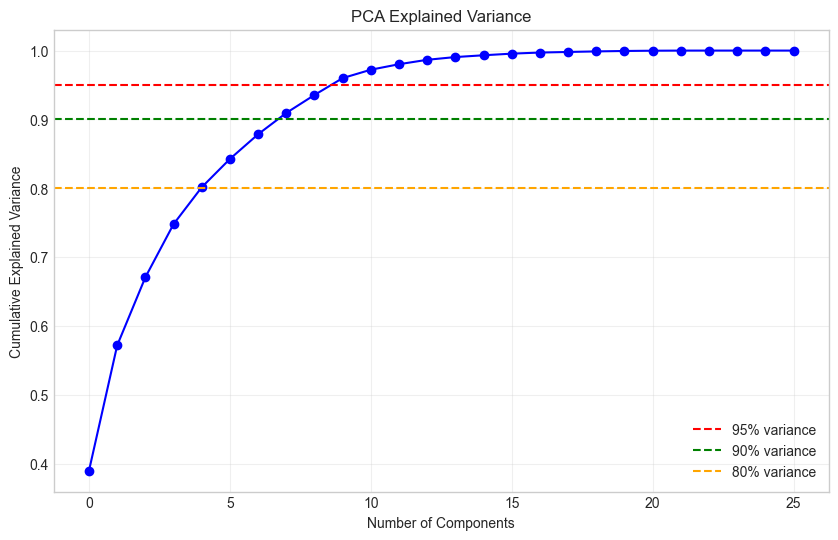


 PCA Results:
   - Components for 95% variance: 10
   - Components for 90% variance: 8
   - Components for 80% variance: 5


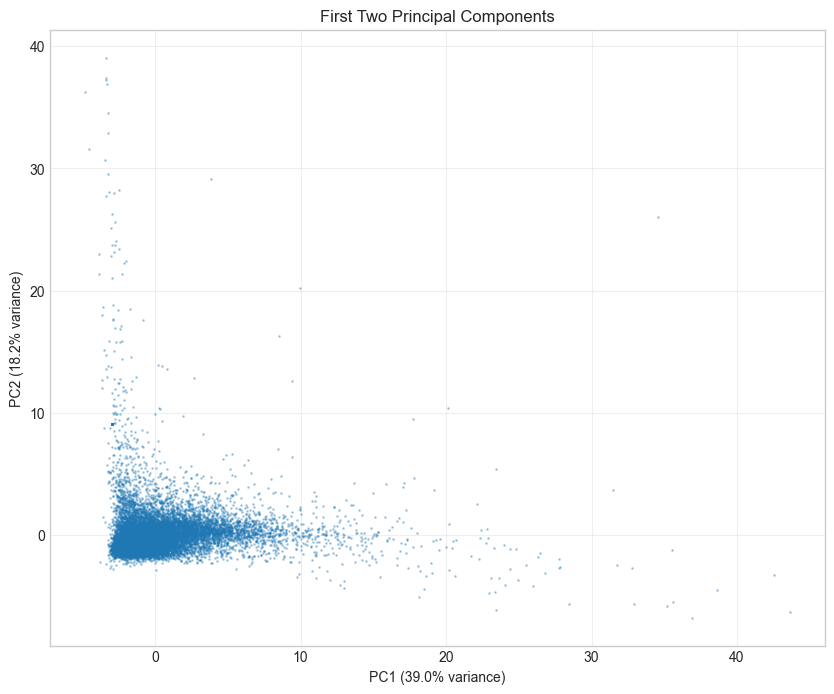

In [9]:
# ## 7. PCA for Dimensionality Reduction

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Normalize features for PCA
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_clean_df[feature_cols])

# Apply PCA
pca = PCA()
pca_result = pca.fit_transform(features_scaled)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.9, color='g', linestyle='--', label='90% variance')
plt.axhline(y=0.8, color='orange', linestyle='--', label='80% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURES_DIR / 'pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Find number of components for different variance thresholds
n_components_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
n_components_90 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90) + 1
n_components_80 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.80) + 1

print(f"\n PCA Results:")
print(f"   - Components for 95% variance: {n_components_95}")
print(f"   - Components for 90% variance: {n_components_90}")
print(f"   - Components for 80% variance: {n_components_80}")

# Plot first two principal components
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3, s=1)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('First Two Principal Components')
plt.grid(True, alpha=0.3)
plt.savefig(FIGURES_DIR / 'pca_first_two_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ## 8. Feature Importance Analysis
# Look at feature loadings for first few PCs

n_pcs_to_show = 5
loadings = pd.DataFrame(
    pca.components_[:n_pcs_to_show].T,
    columns=[f'PC{i+1}' for i in range(n_pcs_to_show)],
    index=feature_cols
)

print("\n📊 Feature Loadings for First 5 Principal Components:")
print(loadings.round(3))

# Find top features for each PC
print("\n🔍 Top 5 features for each PC:")
for pc in range(n_pcs_to_show):
    top_features = loadings.iloc[:, pc].abs().sort_values(ascending=False).head(5)
    print(f"\nPC{pc+1}:")
    for feat, val in top_features.items():
        print(f"   {feat}: {val:.3f}")



📊 Feature Loadings for First 5 Principal Components:
                            PC1    PC2    PC3    PC4    PC5
mean                      0.298 -0.076 -0.025 -0.173  0.085
median                    0.275 -0.097 -0.026 -0.215  0.114
std                       0.300  0.035 -0.003  0.058 -0.129
cv                        0.014  0.366 -0.268  0.012 -0.168
iqr                       0.282 -0.004  0.052  0.052 -0.246
range                     0.276  0.069 -0.091  0.028 -0.010
skewness                 -0.017  0.335 -0.341  0.023  0.119
kurtosis                 -0.017  0.330 -0.370 -0.046  0.031
q25                       0.216 -0.118 -0.066 -0.299  0.285
q75                       0.305 -0.064  0.002 -0.118 -0.023
q90                       0.312 -0.038  0.001 -0.069 -0.034
q95                       0.312 -0.020 -0.009 -0.046 -0.016
weekend_ratio            -0.005  0.071 -0.109 -0.041 -0.145
summer_peak              -0.095 -0.017 -0.076 -0.288  0.478
winter_peak              -0.000 -0.000  0.000 

In [11]:
# ## 9. Select Features for Clustering
# Based on correlation analysis, we can remove highly correlated features
# to reduce redundancy
# Identify features to keep (manually selected based on correlation analysis)

features_to_keep = [
    'mean',           # Central tendency
    'cv',             # Relative variability
    'skewness',       # Shape
    'kurtosis',       # Shape
    'weekend_ratio',  # Weekly pattern
    'summer_peak',    # Seasonal pattern
    'winter_peak',    # Seasonal pattern
    'trend_slope',    # Trend
    'seasonal_strength_weekly',  # Seasonality
    'n_peaks',        # Peak frequency
    'peak_height_ratio',  # Peak magnitude relative to mean
    'zero_percentage',    # Zero consumption
    'avg_zero_run'        # Pattern of zeros
]

# Check which features are available
available_features = [f for f in features_to_keep if f in feature_cols]
print(f"\n Selected {len(available_features)} features for clustering:")
for f in available_features:
    print(f"   - {f}")

# Create reduced feature set
features_reduced = features_clean_df[['ID'] + available_features].copy()

# Normalize reduced features
features_reduced_norm, scaler_reduced = normalize_features(features_reduced, method='zscore')



📋 Selected 13 features for clustering:
   - mean
   - cv
   - skewness
   - kurtosis
   - weekend_ratio
   - summer_peak
   - winter_peak
   - trend_slope
   - seasonal_strength_weekly
   - n_peaks
   - peak_height_ratio
   - zero_percentage
   - avg_zero_run

NORMALIZING FEATURES (method: zscore)
✅ Normalized 13 features


In [12]:
 ## 10. Save Features
# Save all features
features_clean_df.to_csv(PROCESSED_DATA_DIR / 'household_features_clean.csv', index=False)
print(f"✅ Saved clean features to {PROCESSED_DATA_DIR / 'household_features_clean.csv'}")

# Save reduced features
features_reduced.to_csv(PROCESSED_DATA_DIR / 'household_features_reduced.csv', index=False)
features_reduced_norm.to_csv(PROCESSED_DATA_DIR / 'household_features_reduced_norm.csv', index=False)
print(f"✅ Saved reduced features to {PROCESSED_DATA_DIR / 'household_features_reduced.csv'}")
print(f"✅ Saved normalized reduced features to {PROCESSED_DATA_DIR / 'household_features_reduced_norm.csv'}")

# Save PCA results
pca_results = pd.DataFrame(
    pca_result[:, :n_components_95],
    columns=[f'PC{i+1}' for i in range(n_components_95)]
)
pca_results['ID'] = features_clean_df['ID'].values
pca_results.to_csv(PROCESSED_DATA_DIR / 'pca_results.csv', index=False)
print(f"✅ Saved PCA results ({n_components_95} components) to {PROCESSED_DATA_DIR / 'pca_results.csv'}")

✅ Saved clean features to /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/processed/household_features_clean.csv
✅ Saved reduced features to /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/processed/household_features_reduced.csv
✅ Saved normalized reduced features to /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/processed/household_features_reduced_norm.csv
✅ Saved PCA results (10 components) to /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/processed/pca_results.csv


In [13]:
# ## 11. Summary
print("="*60)
print("FEATURE EXTRACTION SUMMARY")
print("="*60)
print(f"\n📊 Dataset: {len(features_df)} households")
print(f"\n📈 Original features: {len(feature_cols)}")
print(f"\n🔧 After cleaning: {len(features_clean_df.columns) - 1} features")
print(f"\n📉 PCA compression: {len(feature_cols)} → {n_components_95} dimensions (95% variance)")
print(f"\n🎯 Selected features for clustering: {len(available_features)}")
print(f"\n✅ All files saved to: {PROCESSED_DATA_DIR}")

print("\n" + "="*60)
print("FEATURE EXTRACTION COMPLETE")
print("="*60)

FEATURE EXTRACTION SUMMARY

📊 Dataset: 17547 households

📈 Original features: 26

🔧 After cleaning: 26 features

📉 PCA compression: 26 → 10 dimensions (95% variance)

🎯 Selected features for clustering: 13

✅ All files saved to: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/data/processed

FEATURE EXTRACTION COMPLETE
